# Проект: Анализ результатов A/B теста

# Цели исследования: 
- Приоретизация гипотез для увеличения выручки интернет магазина
- Анализ результатов A/B тестирования, формирование общего вывода

# План исследования:
1. Загрузка данных / разведочный анализ
2. Предобработка данных
- Использование фреймворка ICE для приоритизации гипотез. Сортировка по убыванию приоритета.
- Использование фреймворка RICE для приоритизации гипотез. Сортировка по убыванию приоритета.
- Узнать, как изменилась приоритизация гипотез при применении RICE вместо ICE. Найти причину произошедшего
3. Анализ результатов A/B тестирования.
- Построение графика кумулятивной выручки по группам. Выводы и предположения.
- Построение графика кумулятивного среднего чека по группам. Выводы и предположения.
- Построение графика относительного изменения кумулятивного среднего чека группы B к группе A. Выводы и предположения.
- Построение графика кумулятивного среднего количества заказов на посетителя по группам. Выводы и предположения.
- Построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Выводы и предположения.
- Построение точечного графика количества заказов по пользователям. Выводы и предположения.
- Посчитать 95-й и 99-й перцентили количества заказов на пользователя. Выбор границы для определения аномальных пользователей.
- Построение точечного графика стоимостей заказов. Выводы и предположения.
- Посчитать 95-й и 99-й перцентили стоимости заказов. Выбор границы для определения аномальных заказов.
- Вычисление статистической значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Выводы и предположения.
- Посчитать статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Выводы и предположения.
- Посчитать статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Выводы и предположения.
- Посчитать статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Выводы и предположения.
- Принятие решения по результатам теста, обоснование. Варианты решений:
- Остановить тест, зафиксировать победу одной из групп.
- Остановить тест, зафиксировать отсутствие различий между группами.
- Продолжить тест.
4. Общий вывод.

# Документация
1. Файл /datasets/hypothesis.csv
- Hypothesis — краткое описание гипотезы;
- Reach — охват пользователей по 10-балльной шкале;
- Impact — влияние на пользователей по 10-балльной шкале;
- Confidence — уверенность в гипотезе по 10-балльной шкале;
- Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

2. Файл /datasets/orders.csv. 
- transactionId — идентификатор заказа;
- visitorId — идентификатор пользователя, совершившего заказ;
- date — дата, когда был совершён заказ;
- revenue — выручка заказа;
- group — группа A/B-теста, в которую попал заказ.

3. /datasets/visitors.csv. 
- date — дата;
- group — группа A/B-теста;
- visitors — количество пользователей в указанную дату в указанной группе A/B-теста

# Загрузка данных / разведочный анализ

In [1]:
import pandas as pd
import numpy as np
import math
from matplotlib.widgets import Cursor
import plotly.express as px
import scipy.stats as stats
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns # импорт необходимых для работы инструментов 

In [2]:
data = pd.read_csv("/datasets/hypothesis.csv") # загрузка фрейма

In [3]:
data # просмотр фрейма

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


# Предобработка данных

In [4]:
data.columns = data.columns.str.lower() # приведение к нижнему регистру 

In [5]:
data

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


Значения приведены к нижнему регистру для удобства анализа

In [6]:
data.isnull().sum() # поиск пропусков

hypothesis    0
reach         0
impact        0
confidence    0
efforts       0
dtype: int64

Пропуски отсутствуют

In [7]:
data.duplicated().sum() # поиск явных дубликатов

0

Дубликаты не зарегистрированны

Произведена небольшая предобработка, фрейм выглядит "чистым", пропуски отсутствуют, дубликаты отсутствуют. В следующих шагах коснёмся приоретизации гипотез 

# Приоретизация гипотез

In [8]:
data["ICE"] = data["ICE"] = round((data["impact"] * data["confidence"]) / data["efforts"], 2)
print(data[["hypothesis","ICE"]].sort_values(by = "ICE", ascending = False)) # применение ICE для приоретизации

                                          hypothesis    ICE
8  Запустить акцию, дающую скидку на товар в день...  16.20
0  Добавить два новых канала привлечения трафика,...  13.33
7  Добавить форму подписки на все основные страни...  11.20
6  Показать на главной странице баннеры с актуаль...   8.00
2  Добавить блоки рекомендаций товаров на сайт ин...   7.00
1  Запустить собственную службу доставки, что сок...   2.00
5  Добавить страницу отзывов клиентов о магазине,...   1.33
3  Изменить структура категорий, что увеличит кон...   1.12
4  Изменить цвет фона главной страницы, чтобы уве...   1.00


После оценки гипотез с помощью фреймворка ICE, гипотеза №8 заняла первое место благодаря одинаково высоким показателям impact и confidence при среднем уровне efforts. Следующей по приоритету стала гипотеза №0, поскольку у нее более высокие затраты усилий. Третью позицию занимает гипотеза №7. Следующим шагом используем RICE для приоретизации

In [9]:
data["RICE"] = round((data["impact"] * data["reach"] * data["confidence"]) / data["efforts"], 2)
print(data[["hypothesis","RICE"]].sort_values(by = "RICE", ascending = False))

                                          hypothesis   RICE
7  Добавить форму подписки на все основные страни...  112.0
2  Добавить блоки рекомендаций товаров на сайт ин...   56.0
0  Добавить два новых канала привлечения трафика,...   40.0
6  Показать на главной странице баннеры с актуаль...   40.0
8  Запустить акцию, дающую скидку на товар в день...   16.2
3  Изменить структура категорий, что увеличит кон...    9.0
1  Запустить собственную службу доставки, что сок...    4.0
5  Добавить страницу отзывов клиентов о магазине,...    4.0
4  Изменить цвет фона главной страницы, чтобы уве...    3.0


После приоритизации гипотез с использованием фреймворка RICE на первое место вышла гипотеза №7. Отличие метода RICE от ICE заключается в том, что при использовании RICE учитывается охват пользователей (reach), который отдел маркетинга оценил на максимально возможный балл. Также гипотеза №2 заняла вторую позицию по важности. В то же время гипотеза №8 опустилась на пятое место. С приоретизацией закончили, переходим к анализу A/B тестирования

# Анализ A/B тестирования

In [10]:
orders_data = pd.read_csv("/datasets/orders.csv") # загрузка фреймов
visitors_data = pd.read_csv("/datasets/visitors.csv")

Сначала поближе познакомимся с orders

In [11]:
orders_data # проверка результата 

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
...,...,...,...,...,...
1192,2662137336,3733762160,2019-08-14,6490,B
1193,2203539145,370388673,2019-08-14,3190,A
1194,1807773912,573423106,2019-08-14,10550,A
1195,1947021204,1614305549,2019-08-14,100,A


Перед началом анализа A/B тестов необходимо ознакомиться с основными свойствами фрейма и провести предобработку, если это понадобится.

In [12]:
orders_data.info() # изучение характеристик фрейма

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


Сразу можно обратить внимание на поле "date", тип данных не соответствует. Проверим пропуски и дубликаты 

In [13]:
orders_data.isnull().sum() # поиск пропусокв

transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

Пропусков также нет

In [14]:
orders_data.duplicated().sum() # поиск дубликатов 

0

Дубликатов также нет

In [15]:
orders_data["date"] = pd.to_datetime(orders_data["date"], format="%Y-%m-%dT") # приведение поля к корректному типу данных
orders_data.rename(columns={"transactionId": "transaction_id", "visitorId": "visitor_id"}, inplace = True) # + немного отредактируем названия полей

In [16]:
orders_data.info() # проверка результата

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


Преобразование успешно. Переходим к visitors_data

In [17]:
visitors_data # просмотр фрейма

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
...,...,...,...
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490


In [18]:
visitors_data.info() # просмотр свойств фрема

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


У date опять некорректный тип данных. Посмотрим на пропуски и дубликаты

In [19]:
visitors_data.isnull().sum() # поиск пропусков 

date        0
group       0
visitors    0
dtype: int64

Пропусков нет

In [20]:
visitors_data.duplicated().sum() #  поиск дубликатов

0

Дубликтов и пропусков нет, переходим к преобразованию типа данных в поле date

In [21]:
visitors_data["date"] = pd.to_datetime(visitors_data["date"], format = "%Y-%m-%dT") # преобразование типа данных

In [22]:
visitors_data.info() # проверка результата

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


Предобработка проведена, переходим к анализу А/В теста но сначала проверим, не попадают ли у нас пользователи в обе группы?

In [23]:
orders_data_A =  orders_data[orders_data.group == "A"] # группировка по А

In [24]:
orders_data_B = orders_data[orders_data.group == "B"] # группировка по B

In [25]:
orders_data_A_un = orders_data_A.visitor_id.unique()
len(orders_data_A_un) # замер длинны сета

503

In [26]:
orders_data_B_un = orders_data_B.visitor_id.unique()
len(orders_data_B_un) # замер длины сета

586

In [27]:
both = []
for each in orders_data_A.visitor_id.unique():
    if each in orders_data_B.visitor_id.unique():
        both.append(each) # подсчёт пользователей в обеих группах 

In [28]:
len(both) # замер длины

58

58 пользователей оказались в обеих группах. Их следует исключить, поскольку они не предоставляют ясной картины по результатам теста: мы не можем с уверенностью определить, какой именно фактор проверки повлиял на их решение.

In [29]:
orders_data.info() # посмотрим на сет до удаления

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


In [30]:
orders_data = orders_data[~orders_data.visitor_id.isin(both)] # удаление пользователей 

In [31]:
orders_data.info() # проверка результата

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1016 non-null   int64         
 1   visitor_id      1016 non-null   int64         
 2   date            1016 non-null   datetime64[ns]
 3   revenue         1016 non-null   int64         
 4   group           1016 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 47.6+ KB


# Анализ результатов A/B тестирования

In [32]:
uniq_duo = orders_data[['date','group']].drop_duplicates() 
uniq_duo.head() # создание массива уникальных пар 

,date,group
0,2019-08-15,B
7,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A


Переходим к сбору кумулятивных по дням

In [33]:
ordersAgg = uniq_duo.apply(lambda x: orders_data[np.logical_and(orders_data["date"] <= x["date"], orders_data["group"] == x["group"])].agg({"date" : "max", "group" : "max", "transaction_id" : "nunique", "visitor_id" : "nunique", "revenue" : "sum"}), axis = 1).sort_values(by = ["date","group"])

In [34]:
visitorsAgg = uniq_duo.apply(lambda x: visitors_data[np.logical_and(visitors_data["date"] <= x["date"], visitors_data["group"] == x["group"])].agg({"date" : "max", "group" : "max", "visitors" : "sum"}), axis = 1).sort_values(by = ["date","group"]) # сбор ком-ой 

Теперь объеденим таблицы

In [35]:
cumulativeData = ordersAgg.merge(visitorsAgg, left_on = ["date", "group"], right_on = ["date", "group"]) # объёдинение 
cumulativeData.columns = ["date", "group", "orders", "buyers", "revenue", "visitors"]
cumulativeData # проверка резульата

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845
...,...,...,...,...,...,...
57,2019-08-29,B,510,490,4746610,17708
58,2019-08-30,A,460,437,3311413,18037
59,2019-08-30,B,531,511,4955833,18198
60,2019-08-31,A,468,445,3364656,18736


Переходим к проектированию графиков 

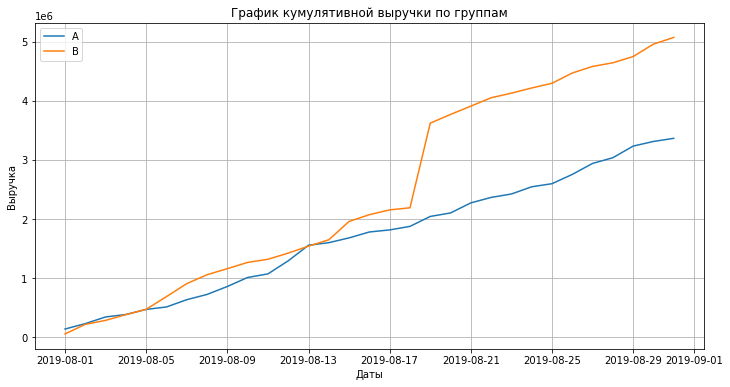

In [36]:
cumulativeRevenueA = cumulativeData[cumulativeData["group"]=="A"][["date","revenue", "orders"]] 
# кумулятивные заказы и выручка для A
cumulativeRevenueB = cumulativeData[cumulativeData["group"]=="B"][["date","revenue", "orders"]]
# кумулятивные заказы и выручка для В

# График для А
plt.figure(figsize=(12, 6))
plt.plot(cumulativeRevenueA["date"], cumulativeRevenueA["revenue"], label = "A")

# СГрафик для В
plt.plot(cumulativeRevenueB["date"], cumulativeRevenueB["revenue"], label = "B")
plt.title("График кумулятивной выручки по группам")
plt.xlabel("Даты")
plt.ylabel("Выручка")
plt.legend()
plt.grid(True)
plt.show()

Выручка постепенно растет на протяжении всего теста, за исключением одного промежутка с 18 по 19 августа, когда наблюдается резкий скачок данных о выручке группы В. Это может быть связано либо с внезапным увеличением количества заказов, либо с оформлением в этот период нескольких очень дорогих заказов.

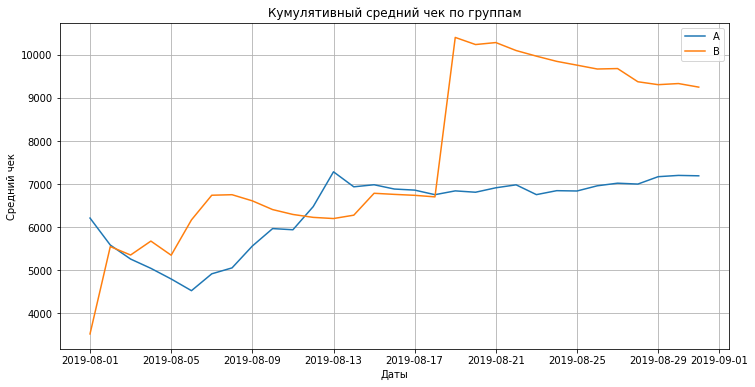

In [37]:
plt.figure(figsize=(12, 6)) # проектирование графика кумулятивного среднего чека по группам
plt.plot(cumulativeRevenueA["date"], cumulativeRevenueA["revenue"]/cumulativeRevenueA["orders"], label = "A")
plt.plot(cumulativeRevenueB["date"], cumulativeRevenueB["revenue"]/cumulativeRevenueB["orders"], label = "B")
plt.title("Кумулятивный средний чек по группам")
plt.xlabel("Даты")
plt.ylabel("Средний чек")
          
plt.legend()
plt.grid(True)
plt.show()

К концу теста средний чек становится более стабильным: для группы А он установился и продолжает оставаться на этом уровне, а для группы В наблюдается снижение. Вероятно, в середине теста в группу В попали крупные заказы (что отражается резким всплеском на графике), поэтому ей требуется больше данных для определения реального среднего чека и его стабилизации. В целом, на протяжении всего теста средний чек группы В превышает показатель группы А, хотя в период с 11 по 13 сентября отмечается снижение среднего чека у группы В и одновременный рост у группы А.

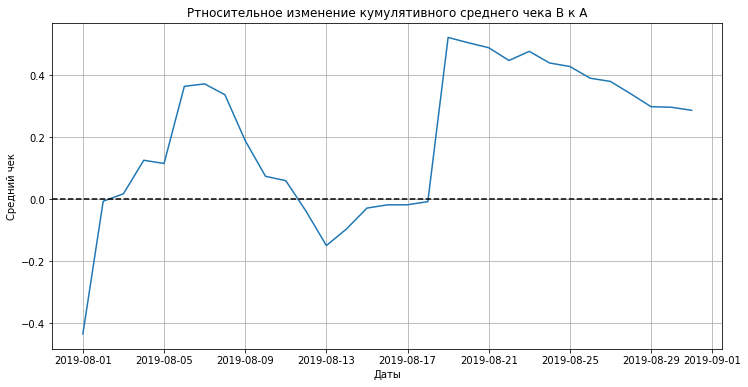

In [38]:
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on = "date", right_on = "date", how = "left", suffixes = ["A", "B"])
plt.figure(figsize=(12, 6))
# выведение отношения средних чеков
plt.plot(mergedCumulativeRevenue["date"], (mergedCumulativeRevenue["revenueB"]/mergedCumulativeRevenue["ordersB"])/(mergedCumulativeRevenue["revenueA"]/mergedCumulativeRevenue["ordersA"])-1)
plt.axhline(y = 0, color = "black", linestyle = "--")
plt.title("Ртносительное изменение кумулятивного среднего чека B к A")
plt.xlabel("Даты")
plt.ylabel("Средний чек")
plt.grid(True)
plt.show() # выведение графика

На нескольких участках графика наблюдаются резкие колебания в различиях между сегментами. В целом, кумулятивные показатели среднего чека группы В превышают соответствующие данные группы А.

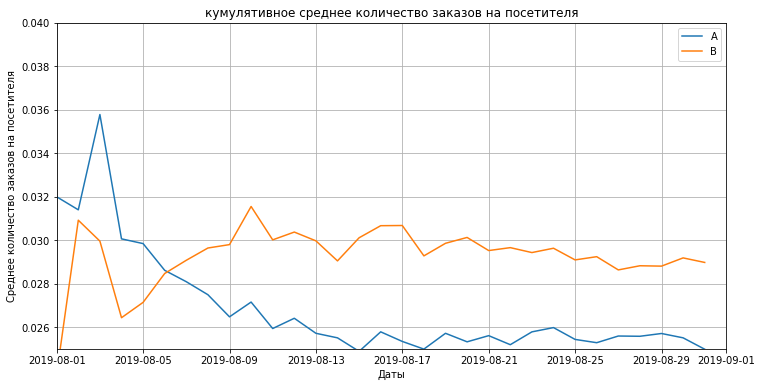

In [39]:
cumulativeData["conversion"] = cumulativeData["orders"]/cumulativeData["visitors"]
cumulativeDataA = cumulativeData[cumulativeData["group"]== "A"]
# строим график кумулятивного среднего количества заказов на посетителя по группам.
cumulativeDataB = cumulativeData[cumulativeData["group"]== "B"]
plt.figure(figsize=(12, 6))
plt.plot(cumulativeDataA["date"], cumulativeDataA["conversion"], label = "A")
plt.plot(cumulativeDataB["date"], cumulativeDataB["conversion"], label= "B")
plt.legend()
plt.axis([pd.to_datetime("2019-08-01"), pd.to_datetime("2019-09-01"),0.025, 0.04])
plt.title("кумулятивное среднее количество заказов на посетителя")
plt.xlabel("Даты")
plt.ylabel("Cреднее количество заказов на посетителя")
plt.grid(True)
plt.show()

В результате получился симметричный график: обе группы колебались около одного уровня, однако затем у группы В среднее число заказов выросло и стабилизировалось, в то время как у группы А оно снизилось, но также осталось на фиксированном уровне.

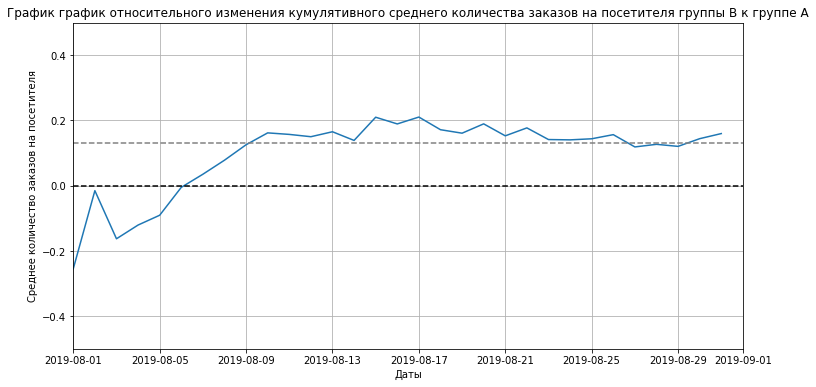

In [40]:
mergedCumulativeConversions = cumulativeDataA[["date","conversion"]].merge(cumulativeDataB[["date","conversion"]], left_on = "date", right_on = "date", how = "left", suffixes = ["A", "B"])
plt.figure(figsize=(12, 6))
plt.plot(mergedCumulativeConversions["date"], mergedCumulativeConversions["conversionB"]/mergedCumulativeConversions["conversionA"]-1, label = "Относительный прирост кумулятивного среднего количества заказов на посетителя группы B, относительно A")
plt.axhline(y=0, color = "black", linestyle = "--")
plt.axhline(y=0.13, color = "grey", linestyle = "--")
plt.axis([pd.to_datetime("2019-08-01"), pd.to_datetime("2019-09-01"), -0.5, 0.5])
plt.title("График график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A")
plt.xlabel("Даты")
plt.ylabel("Cреднее количество заказов на посетителя")
plt.grid(True)
plt.show() # график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

В начале теста группа В то уступала, то опережала группу А, но затем вышла вперёд. В итоге можно заключить, что соотношение среднего числа заказов на посетителя стабилизировалось на уровне 0,13.

In [41]:
users_orders = orders_data.groupby("visitor_id").agg(orders_data = ("transaction_id","nunique")).reset_index().sort_values(by = "orders_data", ascending = False)
users_orders # группировка по количеству заказов у пользователя

,visitor_id,orders_data
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
...,...,...
331,1438226485,1
332,1452540367,1
333,1455323168,1
334,1455861274,1


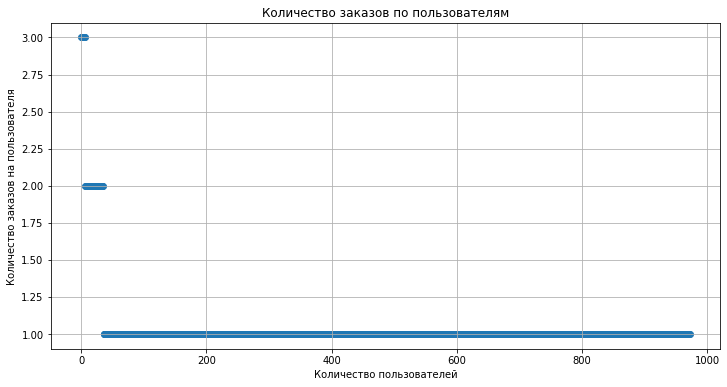

In [42]:
x = pd.Series(range(0,len(users_orders)))
plt.figure(figsize=(12, 6))
# проектирование скатерплота
plt.scatter(x, users_orders["orders_data"])
plt.title("Количество заказов по пользователям")
plt.xlabel("Количество пользователей")
plt.ylabel("Количество заказов на пользователя")
plt.grid(True)
plt.show()

Большинство пользователей оформляли по одному заказу, однако наблюдаются аномально высокие показатели — от 8 до 11 заказов на одного пользователя. Чтобы определить, какое количество заказов считать аномальным, мы воспользуемся анализом процентилей.

In [43]:
print(np.percentile(users_orders["orders_data"], [95, 99]))  #поиск перцентилей

[1. 2.]


Не более 5% пользователей оформляли более двух заказов, а менее 1% — более четырех. В качестве верхней границы количества заказов на одного пользователя разумно установить значение в 4, чтобы исключить аномальных пользователей, поскольку выбросы встречаются крайне редко.

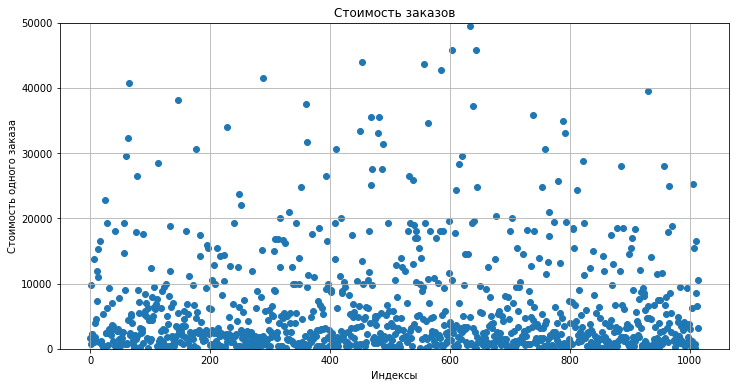

In [44]:
x = pd.Series(range(0, len(orders_data["revenue"])))
# построение скатерплота стоимости заказов
plt.figure(figsize=(12, 6))
plt.scatter(x, orders_data["revenue"])
plt.title("Стоимость заказов")
plt.xlabel("Индексы")
plt.ylabel("Стоимость одного заказа")
plt.grid(True)
plt.ylim(0,50000) #
plt.show()

Несмотря на то, что большинство заказов по стоимости находятся в диапазоне около 20 000, все же существует значительное количество заказов с суммой от 20 000 до 60 000.

In [45]:
print(np.percentile(orders_data["revenue"], [95, 99]))  # выведение перцентилей

[26785. 53904.]


Менее 5% пользователей оформляли заказы на сумму свыше 28 000, а менее 1% — на сумму более 58 233. В качестве верхней границы стоимости заказа разумно установить значение 58 233,2, чтобы исключить аномальных пользователей. Поскольку выбросы являются единичными и данных для их фильтрации много, мы не будем проводить дополнительную очистку.

In [46]:
visitorsADaily = visitors_data[visitors_data["group"] == "A"][["date", "visitors"]]
visitorsADaily.columns = ["date", "visitorsPerDateA"]

visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily["date"] <= x["date"]].agg(
        {"date": "max", "visitorsPerDateA": "sum"}
    ),
    axis=1,
)
visitorsACummulative.columns = ["date", "visitorsCummulativeA"]

visitorsBDaily = visitors_data[visitors_data["group"] == "B"][["date", "visitors"]]
visitorsBDaily.columns = ["date", "visitorsPerDateB"]

visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily["date"] <= x["date"]].agg(
        {"date": "max", "visitorsPerDateB": "sum"}
    ),
    axis=1,
)

ordersADaily = (
    orders_data[orders_data["group"] == "A"][["date", "transaction_id", "visitor_id", "revenue"]]
    .groupby("date", as_index=False)
    .agg({"transaction_id": pd.Series.nunique, "revenue": "sum"})
)
ordersADaily.columns = ["date", "ordersPerDateA", "revenuePerDateA"]

ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily["date"] <= x["date"]].agg(
        {"date": "max", "ordersPerDateA": "sum", "revenuePerDateA": "sum"}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    "date",
    "ordersCummulativeA",
    "revenueCummulativeA",
]

ordersBDaily = (
    orders_data[orders_data["group"] == "B"][["date", "transaction_id", "visitor_id", "revenue"]]
    .groupby("date", as_index=False)
    .agg({"transaction_id": pd.Series.nunique, "revenue": "sum"})
)
ordersBDaily.columns = ["date", "ordersPerDateB", "revenuePerDateB"]

ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily["date"] <= x["date"]].agg(
        {"date": "max", "ordersPerDateB": "sum", "revenuePerDateB": "sum"}
    ),
    axis=1,
).sort_values(by=["date"])
ordersBCummulative.columns = [
    "date",
    "ordersCummulativeB",
    "revenueCummulativeB",
]

data_second = (
    ordersADaily.merge(
        ordersBDaily, left_on="date", right_on = "date", how = "left"
    )
    .merge(ordersACummulative, left_on="date", right_on="date", how="left")
    .merge(ordersBCummulative, left_on="date", right_on="date", how="left")
    .merge(visitorsADaily, left_on="date", right_on="date", how="left")
    .merge(visitorsBDaily, left_on="date", right_on="date", how="left")
    .merge(visitorsACummulative, left_on="date", right_on="date", how="left")
    .merge(visitorsBCummulative, left_on="date", right_on="date", how="left")
)

data_second.head()

,date,ordersPerDateA,revenuePerDateA,ordersPerDateB,revenuePerDateB,ordersCummulativeA,revenueCummulativeA,ordersCummulativeB,revenueCummulativeB,visitorsPerDateA,visitorsPerDateB_x,visitorsCummulativeA,visitorsPerDateB_y
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


Сформирована таблица с следующими столбцами: date — дата; ordersPerDateA — количество заказов в выбранную дату в группе A; revenuePerDateA — общая выручка за выбранную дату в группе A; ordersPerDateB — количество заказов в выбранную дату в группе B; revenuePerDateB — общая выручка за выбранную дату в группе B; ordersCummulativeA — суммарное число заказов до выбранной даты включительно в группе A; revenueCummulativeA — суммарная выручка до выбранной даты включительно в группе A; ordersCummulativeB — суммарное количество заказов до выбранной даты включительно в группе B; revenueCummulativeB — суммарная выручка до выбранной даты включительно в группе B; visitorsPerDateA — число пользователей в выбранную дату в группе A; visitorsPerDateB — число пользователей в выбранную дату в группе B; visitorsCummulativeA — число пользователей до выбранной даты включительно в группе A; visitorsCummulativeB — число пользователей до выбранной даты включительно в группе B.

Далее мы проведем анализ статистической значимости различий в среднем количестве заказов между группами. Для этого создадим два датафрейма: ordersByUsersA и ordersByUsersB, содержащие столбцы 'visitor_id' и 'orders'. В них для пользователей, сделавших хотя бы один заказ, укажем количество совершённых заказов.

In [47]:
ordersByUsersA = (
    orders_data[orders_data["group"] == "A"]
    .groupby("visitor_id", as_index=False)
    .agg({"transaction_id": pd.Series.nunique})
)
ordersByUsersA.columns = ["visitor_id", "orders"]
# число сделанных заказов
ordersByUsersB = (
    orders_data[orders_data["group"] == "B"]
    .groupby("visitor_id", as_index = False)
    .agg({"transaction_id": pd.Series.nunique})
)
ordersByUsersB.columns = ["visitor_id", "orders"]

Объявим переменные sampA и sampB, в которых для пользователей из каждой группы будет указано количество заказов. Пользователям, не сделавшим заказов, присвоим значение ноль. Это необходимо для подготовки выборок к проведению теста Манна-Уитни.

Мы выбираем метод Манна-Уитни, поскольку предварительный анализ показал наличие значительных выбросов и несоблюдение нормальности распределения по выручке. В условиях наличия больших выбросов классические алгебраические метрики, такие как t-тест, работают плохо и могут давать искажённые результаты.

In [48]:
sampA = pd.concat([
    ordersByUsersA['orders'],
    pd.Series(
        np.zeros(data_second['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])),
        name='orders'
    )
], axis=0) # подготовка отдельных переменных для критерия Манна Уитни

sampB = pd.concat([
    ordersByUsersB['orders'],
    pd.Series(
        np.zeros(data_second['visitorsPerDateB_x'].sum() - len(ordersByUsersB['orders'])),
        name='orders'
    )
], axis=0)
 

Теперь приступим к вычислению статистической значимости.
Нулевая гипотеза: «На основе исходных данных отсутствуют статистически значимые различия в конверсии между группами».
Альтернативная гипотеза: «На основе исходных данных возможны различия в конверсии между группами».
Уровень значимости устанавливаем равным 0,05.

In [49]:
p = stats.mannwhitneyu(sampA, sampB)[1]

print("p: {0:.3f}".format(p))
mean_ratio = sampB.mean() / sampA.mean() - 1
print("Отношение средних значений: {0:.3f}".format(mean_ratio))

alpha = 0.05
if (p < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными") 
# применение критерия, выведение p, вывод отношения средних значений

p: 0.011
Отношение средних значений: 0.160
Отвергаем нулевую гипотезу: между группами есть разница


Рассмотрим статистическую значимость различий в среднем чеке заказа между группами на основе исходных данных.
Нулевая гипотеза: «На основе сырых данных отсутствуют статистически значимые различия в среднем чеке между группами».
Альтернативная гипотеза: «На основе сырых данных возможны различия в среднем чеке между группами».
Уровень значимости устанавливаем равным 0,05.

In [50]:
p = stats.mannwhitneyu(orders_data[orders_data['group']=='A']['revenue'], orders_data[orders_data['group']=='B']['revenue'])[1]
mean_rat = orders_data[orders_data['group']=='B']['revenue'].mean()/orders_data[orders_data['group']=='A']['revenue'].mean()-1
print("p: {0:.3f}".format(p))
print("Отношение средних значений: {0:.3f}".format(mean_rat))
# статистичесая значимость различий в среднем чеке заказа между группами по «сырым» данным.
alpha = 0.05
if (p < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

p: 0.829
Отношение средних значений: 0.287
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными


Значение p-value существенно превышает 0,05, что свидетельствует о невозможности отвергнуть нулевую гипотезу и о отсутствии статистически значимых различий в среднем чеке. Тем не менее, средний чек группы А заметно ниже среднего чека группы В.

In [51]:
rev_99th_percentile = orders_data['revenue'].quantile(0.99)
or_99th_percentile = users_orders['orders_data'].quantile(0.99)
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > or_99th_percentile]['visitor_id'],
        ordersByUsersB[ordersByUsersB['orders'] > or_99th_percentile]['visitor_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders_data[orders_data['revenue'] > rev_99th_percentile]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
# статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным.
print(abnormalUsers.head(5))
print(abnormalUsers.shape[0])

1099    148427295
33      249864742
58      611059232
949     887908475
744     888512513
Name: visitor_id, dtype: int64
16


В конечно итоге у нас 15 аномальных пользователей

In [52]:
samp_A = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_second['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

samp_B = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_second['visitorsPerDateB_x'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
) # Подготовка выборок для дальнейшего применения Манна Уитни

И посчитаем показатели по очищенным данным. Сначала статистическую значимость различий в конверсии между группами
Нулевая гипотеза: "по очищенным данным статистически значимых различий в конверсии между группами нет"
Альтернативная гипотеза: "по очищенным данным различия в конверсии между группами возможны"
Уровень статистической значимости определяем равным 0,05

In [53]:
p = stats.mannwhitneyu(samp_A, samp_B)[1]
# применение критерия Манна Уитни к группам 
print("p-value: {0:.3f}".format(p))

mean_rat = samp_B.mean() / samp_A.mean() - 1
print("Отношение средних значений: {0:.3f}".format(mean_rat))

alpha = 0.05
if (p < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

p-value: 0.007
Отношение средних значений: 0.189
Отвергаем нулевую гипотезу: между группами есть разница


Результаты теста по исходным данным — p-value составил 0,017, а отношение средних значений — 0,138. После этого p-value снизился ещё больше, а отношение средних значений увеличилось.

Теперь посчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным
Нулевая гипотеза: "по очищенным данным статистически значимых различий в среднем чеке между группами нет"
Альтернативная гипотеза: "по очищенным данным различия в среднем чеке между группами возможны"
Уровень статистической значимости определяем равным 0,05

In [54]:
p = stats.mannwhitneyu(
    orders_data[
        np.logical_and(
            orders_data['group'] == "A",
            np.logical_not(orders_data["visitor_id"].isin(abnormalUsers)),
        )
    ]["revenue"],
    orders_data[
        np.logical_and(
            orders_data["group"] == "B",
            np.logical_not(orders_data["visitor_id"].isin(abnormalUsers)),
        )
    ]["revenue"],
)[1]

# Вывод p-value
print("p-value: {0:.3f}".format(p))

# Вычисление и вывод отношения средних значений
mean_rat = orders_data[
    np.logical_and(
        orders_data["group"] == "B",
        np.logical_not(orders_data['visitor_id'].isin(abnormalUsers)),
    )
]['revenue'].mean() / orders_data[
    np.logical_and(
        orders_data["group"] == "A",
        np.logical_not(orders_data["visitor_id"].isin(abnormalUsers)),
    )
]["revenue"].mean() - 1

print("Отношение средних значений: {0:.3f}".format(mean_rat))

alpha = 0.05
if (p < alpha):
    print("Отвергаем нулевую гипотезу: между группами есть разница")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными")

p-value: 0.788
Отношение средних значений: -0.032
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными


Результаты теста по исходным данным — p-value составил 0,729, а отношение средних значений — 0,259. Значение p-value практически не изменилось, тогда как отношение средних чеков значительно изменилось: после очистки данных средний чек группы А немного превышает средний чек группы В

# Общий вывод

Есть статистически значимое различие в среднем количестве заказов между группами как по исходным данным, так и после фильтрации аномалий.
После очистки данных это различие усилилось.
Статистическая значимость по среднему чеку:

Статистически значимых различий в среднем чеке между группами не обнаружено ни по «сырым» данным, ни после фильтрации.
Однако после очистки данных отношение средних чеков сместилось в пользу группы А.
Графики и тенденции:

График разницы среднего количества заказов показывает, что результаты группы B лучше, чем у группы A, и есть тенденция к улучшению.
График разницы среднего чека свидетельствует о преимуществах группы B.
Вывод:

Учитывая все вышесказанное, можно считать тест успешным.
Тест можно завершить и признать победу группы B.